# Storage-Aware Smoothing Metrics for Short-Term Estimated WEC Power

This notebook connects estimated wave energy converter (WEC) power variability, short-term forecasts, prediction intervals, and simple storage-aware smoothing metrics.

The goal is not to optimize BESS dispatch or produce final storage sizing. Instead, the notebook asks:

> Given a generic 250 kW WEC proxy, what storage burden is implied if the grid receives a smoother, forecast-informed, or uncertainty-aware version of the WEC power signal?

The analysis uses the 250 kW interpretation scale to express normalized estimated WEC-power results in approximate physical units. These values remain interpretation aids for the simplified WEC proxy, not final device or project ratings.


## 1. Scope, upstream workflow, and smoothing concept

This notebook builds on the previous workflow steps:

* [Literature map and research context](../outputs/pdf/00_literature_map.pdf)
* [Wave-resource data preparation](../outputs/pdf/01_wave_data_preparation.pdf)
* [Estimated WEC power from sea-state conditions](../outputs/pdf/02_wec_power_estimation.pdf)
* [Short-term point forecasting baselines](../outputs/pdf/03_forecasting_baselines.pdf)
* [Prediction intervals and uncertainty estimation](../outputs/pdf/04_prediction_intervals_uncertainty.pdf)
* Storage-aware smoothing metrics

The previous notebooks prepared the wave-resource data, estimated WEC power from sea-state conditions, evaluated short-term point forecasts, and calibrated empirical prediction intervals. This notebook uses those outputs to evaluate how different grid-export target definitions affect ramp-rate reduction and implied storage power, energy, throughput, and simple state-of-charge behavior.

The grid-export target is not prescribed as an arbitrary constant power level. Instead, it is derived from the estimated WEC power signal, point forecasts, or prediction interval bounds. This keeps the smoothing target tied to the available wave-energy resource. The analysis therefore asks how much storage power and energy would be required to transform a variable WEC power signal into a smoother grid-export profile.

The target represents a simplified export setpoint at the point of common coupling (PCC). It should not be interpreted as grid demand, market dispatch, or a validated grid-code requirement.


### Conceptual storage-smoothing balance

```text
Estimated WEC power
      p_wec
        │
        ▼
 ┌──────────────────┐
 │ Smoothing target │───▶ Grid export target
 │  selection rule  │        p_grid
 └──────────────────┘
        │
        ▼
Storage balancing power:
p_st = p_wec - p_grid

p_st > 0  → storage charges / absorbs surplus WEC power
p_st < 0  → storage discharges / supports grid delivery
```

In this notebook, storage is represented as an ideal balancing buffer connected at the grid-export interface. The WEC power is not assumed to pass entirely through storage. Instead, storage absorbs the positive mismatch when estimated WEC power exceeds the selected grid-export target and supplies the negative mismatch when estimated WEC power falls below that target.

The resulting storage power, cumulative energy swing, and state-of-charge trajectory are interpreted as smoothing-implied requirements, not as final BESS sizing results.


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown


pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True


# Paths are relative to the notebooks/ directory.
NOTEBOOK_ID = "notebook_05"

DATA_DIR = Path("../data")
OUTPUTS_DIR = Path("../outputs")

TABLES_DIR = OUTPUTS_DIR / "tables" / NOTEBOOK_ID
FIGURES_DIR = OUTPUTS_DIR / "figures" / NOTEBOOK_ID
NOTEBOOK_OUTPUT_DIR = OUTPUTS_DIR / NOTEBOOK_ID

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# Main input files generated by previous notebooks.
WEC_POWER_PATH = DATA_DIR / "processed" / "leixoes_wec_power_30min_estimated.parquet"
FORECAST_PATH = OUTPUTS_DIR / "notebook_03" / "forecast_predictions.parquet"
INTERVAL_PATH = OUTPUTS_DIR / "notebook_04" / "interval_predictions.parquet"


# Main interpretation scale used throughout this notebook.
RATED_POWER_KW = 250.0

# Main forecast / uncertainty setup used for the storage-aware scenarios.
SELECTED_MODEL = "Ridge"
SELECTED_INTERVAL_METHOD = "ConformalStyle_ModelHorizon"
MAIN_INTERVAL_LEVEL = 0.90

# The input data are on a 30-minute time step.
DT_MINUTES = 30
DT_HOURS = DT_MINUTES / 60

SMOOTHING_WINDOWS_MIN = [30, 60, 120, 240]

SMOOTHING_WINDOW_LABELS = {
    30: "30 min",
    60: "1 h",
    120: "2 h",
    240: "4 h",
}

wec_df = pd.read_parquet(WEC_POWER_PATH)
forecast_df = pd.read_parquet(FORECAST_PATH)
interval_df = pd.read_parquet(INTERVAL_PATH)


# WEC power time series from Notebook 02
wec_df = wec_df[
    [
        "time",
        "wec_power_kw_estimated",
        "wec_power_norm_estimated",
    ]
].copy()

wec_df["time"] = pd.to_datetime(wec_df["time"])

# Alias used in this notebook to make the 250 kW interpretation scale explicit.
wec_df["wec_power_kw_250"] = wec_df["wec_power_kw_estimated"]

wec_df = (
    wec_df
    .dropna(subset=["wec_power_kw_250", "wec_power_norm_estimated"])
    .sort_values("time")
    .reset_index(drop=True)
)


# Point forecasts from Notebook 03
forecast_df = forecast_df[
    [
        "sample_id",
        "origin_time",
        "target_time",
        "horizon_steps",
        "horizon_hours",
        "horizon_label",
        "fold_id",
        "split",
        "model",
        "y_true_norm",
        "y_pred_norm",
        "error_norm",
        "y_true_kw_250",
        "y_pred_kw_250",
        "error_kw_250",
    ]
].copy()

forecast_df["origin_time"] = pd.to_datetime(forecast_df["origin_time"])
forecast_df["target_time"] = pd.to_datetime(forecast_df["target_time"])


# Prediction intervals from Notebook 04
interval_df = interval_df[
    [
        "sample_id",
        "origin_time",
        "target_time",
        "horizon_steps",
        "horizon_hours",
        "horizon_label",
        "fold_id",
        "split",
        "model",
        "interval_method",
        "interval_level",
        "y_true_norm",
        "y_pred_norm",
        "lower_norm",
        "upper_norm",
        "interval_width_norm",
        "y_true_kw_250",
        "y_pred_kw_250",
        "lower_kw_250",
        "upper_kw_250",
        "interval_width_kw_250",
        "covered",
    ]
].copy()

interval_df["origin_time"] = pd.to_datetime(interval_df["origin_time"])
interval_df["target_time"] = pd.to_datetime(interval_df["target_time"])


print(f"Loaded WEC power time series: {wec_df.shape[0]:,} rows")
print(f"Loaded forecast predictions: {forecast_df.shape[0]:,} rows")
print(f"Loaded interval predictions: {interval_df.shape[0]:,} rows")

Loaded WEC power time series: 6,220 rows
Loaded forecast predictions: 102,396 rows
Loaded interval predictions: 615,072 rows


## 2. Smoothing scenarios and storage convention

The grid-export target is defined as a smoother version of the WEC power signal, not as an arbitrary constant power request. Depending on the scenario, the target is derived from the observed estimated WEC power, the selected point forecast, or the lower prediction bound.

The storage balance is defined as:

`p_st = p_wec - p_grid`

where:

* `p_wec` is the observed estimated WEC power.
* `p_grid` is the selected grid-export target.
* `p_st` is the storage balancing power.

The sign convention is:

* `p_st > 0`: WEC power exceeds the grid target, so storage charges.
* `p_st < 0`: WEC power is below the grid target, so storage discharges.

Here, “surplus” means surplus relative to the selected grid-export target. It does not mean surplus relative to grid demand. The target is a simplified export setpoint at the point of common coupling, while storage buffers the mismatch between available WEC power and that target.

The four smoothing scenarios are:

| Scenario                       | Grid-export target                        | Purpose                                                             |
| ------------------------------ | ----------------------------------------- | ------------------------------------------------------------------- |
| A. No smoothing                | `p_grid = p_wec`                          | Raw grid-export baseline with no storage action                     |
| B. Observed-power smoothing    | `p_grid = smooth(p_wec)`                  | Storage needed to deliver a smoother version of observed WEC power  |
| C. Forecast-informed smoothing | `p_grid = smooth(p_forecast)`             | Storage effect of using point forecasts to define the export target |
| D. Uncertainty-aware smoothing | `p_grid = smooth(lower prediction bound)` | Conservative target that accounts for forecast uncertainty          |


## 3. Raw variability and high-ramp baseline

Before defining smoothed grid-export targets, the raw estimated WEC power signal is summarized on the 250 kW interpretation scale.

The ramp between two consecutive 30-minute samples is calculated as:

`ramp(t) = p_wec(t) - p_wec(t-1)`

Large absolute ramps indicate periods where the WEC power changes rapidly. These periods are especially relevant for storage smoothing because they can create large short-term charge or discharge requirements.

There is no single universal threshold for defining a high-ramp event. In this notebook, high-ramp periods are defined as the top 5% of absolute target-to-target WEC power changes. This is a simple statistical definition used to highlight the most storage-relevant ramp tail, not a grid-code ramp-rate limit.


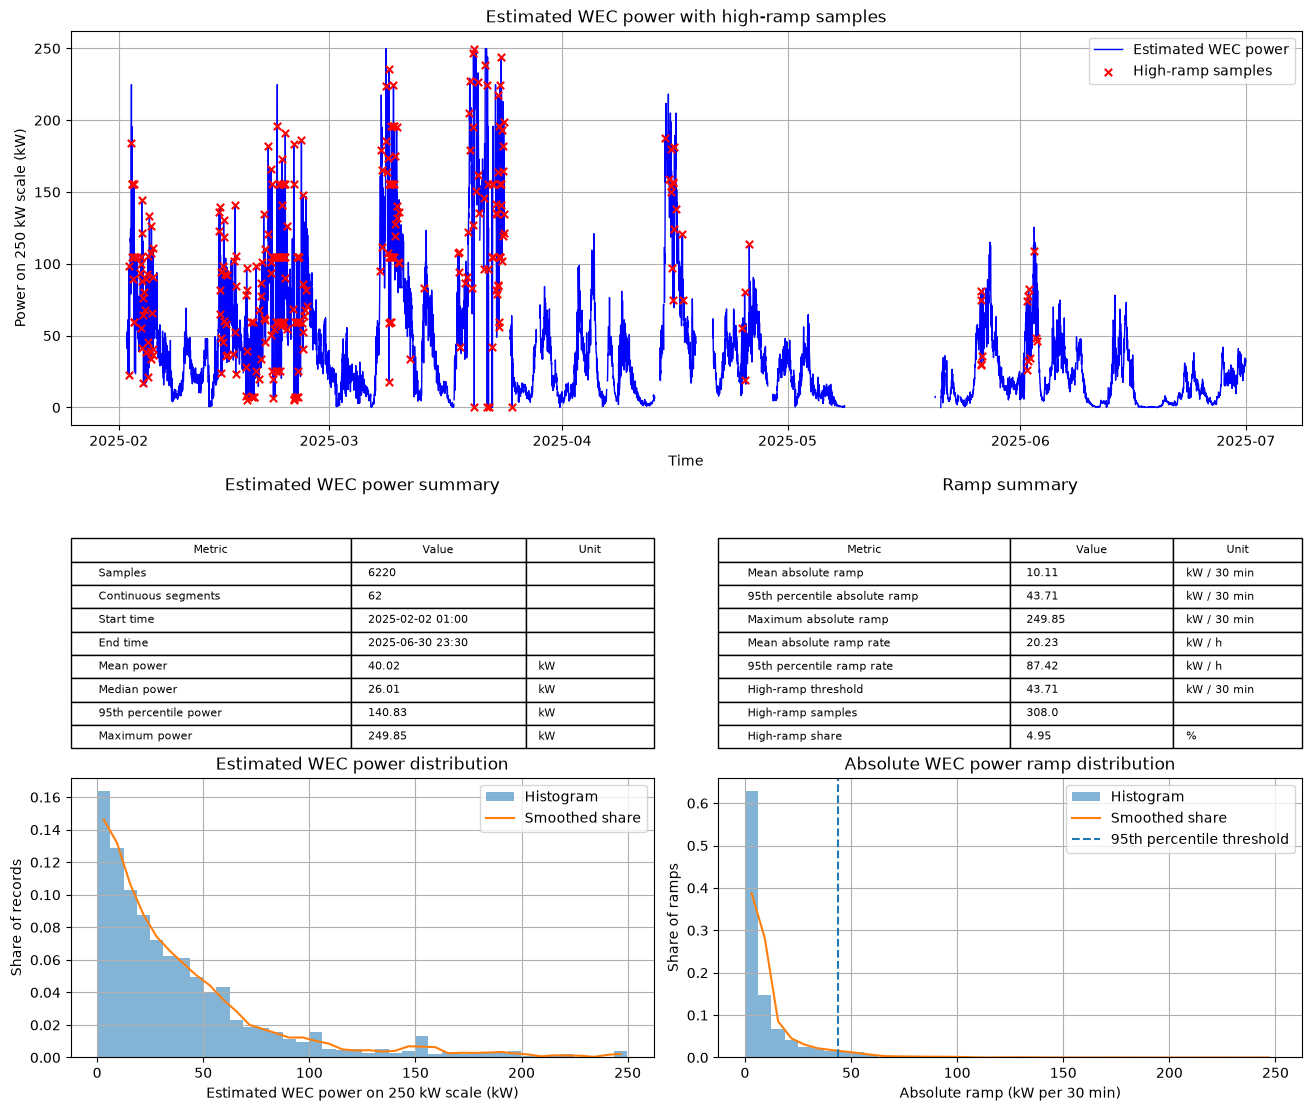

In [9]:
power_df = wec_df[
    [
        "time",
        "wec_power_kw_250",
        "wec_power_norm_estimated",
    ]
].copy()

power_df = power_df.rename(columns={"wec_power_kw_250": "p_wec_kw"})
power_df["time"] = pd.to_datetime(power_df["time"])

# Drop missing values and sort by time.
power_df = (
    power_df
    .dropna(subset=["p_wec_kw", "wec_power_norm_estimated"])
    .sort_values("time")
    .reset_index(drop=True)
)

# Detect gaps and define continuous segments.
power_df["time_diff_minutes"] = power_df["time"].diff().dt.total_seconds() / 60
power_df["is_new_segment"] = power_df["time_diff_minutes"].isna() | (power_df["time_diff_minutes"] > DT_MINUTES)
power_df["segment_id"] = power_df["is_new_segment"].cumsum()

# Compute ramps only within continuous segments.
power_df["ramp_kw_per_step"] = power_df["p_wec_kw"].diff()
power_df.loc[power_df["is_new_segment"], "ramp_kw_per_step"] = np.nan

power_df["abs_ramp_kw_per_step"] = power_df["ramp_kw_per_step"].abs()
power_df["ramp_kw_per_hour"] = power_df["ramp_kw_per_step"] / DT_HOURS
power_df["abs_ramp_kw_per_hour"] = power_df["ramp_kw_per_hour"].abs()

# High-ramp periods: top 5% of absolute ramps.
high_ramp_threshold_kw = power_df["abs_ramp_kw_per_step"].quantile(0.95)
power_df["is_high_ramp"] = power_df["abs_ramp_kw_per_step"] >= high_ramp_threshold_kw
power_df["is_high_ramp"] = power_df["is_high_ramp"].fillna(False)

power_summary = pd.DataFrame(
    [
        ["Samples", len(power_df), ""],
        ["Continuous segments", power_df["segment_id"].nunique(), ""],
        ["Start time", power_df["time"].min().strftime("%Y-%m-%d %H:%M"), ""],
        ["End time", power_df["time"].max().strftime("%Y-%m-%d %H:%M"), ""],
        ["Mean power", power_df["p_wec_kw"].mean(), "kW"],
        ["Median power", power_df["p_wec_kw"].median(), "kW"],
        ["95th percentile power", power_df["p_wec_kw"].quantile(0.95), "kW"],
        ["Maximum power", power_df["p_wec_kw"].max(), "kW"],
    ],
    columns=["Metric", "Value", "Unit"],
)

ramp_summary = pd.DataFrame(
    [
        ["Mean absolute ramp", power_df["abs_ramp_kw_per_step"].mean(), "kW / 30 min"],
        ["95th percentile absolute ramp", power_df["abs_ramp_kw_per_step"].quantile(0.95), "kW / 30 min"],
        ["Maximum absolute ramp", power_df["abs_ramp_kw_per_step"].max(), "kW / 30 min"],
        ["Mean absolute ramp rate", power_df["abs_ramp_kw_per_hour"].mean(), "kW / h"],
        ["95th percentile ramp rate", power_df["abs_ramp_kw_per_hour"].quantile(0.95), "kW / h"],
        ["High-ramp threshold", high_ramp_threshold_kw, "kW / 30 min"],
        ["High-ramp samples", int(power_df["is_high_ramp"].sum()), ""],
        ["High-ramp share", 100 * power_df["is_high_ramp"].mean(), "%"],
    ],
    columns=["Metric", "Value", "Unit"],
)

for summary_df in [power_summary, ramp_summary]:
    summary_df["Value"] = summary_df["Value"].apply(
        lambda x: round(x, 2) if isinstance(x, (int, float, np.floating)) else x
    )

power_summary.to_csv(TABLES_DIR / "raw_wec_power_summary.csv", index=False)
ramp_summary.to_csv(TABLES_DIR / "raw_ramp_summary.csv", index=False)

fig = plt.figure(figsize=(13, 11), constrained_layout=True)
gs = fig.add_gridspec(
    nrows=3,
    ncols=2,
    height_ratios=[2.4, 1.45, 1.7],
)

# ------------------------------------------------------------------
# Row 1: time series with high-ramp samples
# ------------------------------------------------------------------
ax_ts = fig.add_subplot(gs[0, :])

first_segment = True
for _, segment_df in power_df.groupby("segment_id"):
    ax_ts.plot(
        segment_df["time"],
        segment_df["p_wec_kw"],
        linewidth=1,
        color="blue",
        label="Estimated WEC power" if first_segment else None,
    )
    first_segment = False

high_ramp_points = power_df[power_df["is_high_ramp"]]

ax_ts.scatter(
    high_ramp_points["time"],
    high_ramp_points["p_wec_kw"],
    marker="x",
    s=28,
    color="red",
    label="High-ramp samples",
    zorder=3,
)

ax_ts.set_title("Estimated WEC power with high-ramp samples")
ax_ts.set_xlabel("Time")
ax_ts.set_ylabel("Power on 250 kW scale (kW)")
ax_ts.legend()

# ------------------------------------------------------------------
# Row 2: summary tables
# ------------------------------------------------------------------
ax_power_table = fig.add_subplot(gs[1, 0])
ax_ramp_table = fig.add_subplot(gs[1, 1])

ax_power_table.axis("off")
ax_ramp_table.axis("off")

power_table = ax_power_table.table(
    cellText=power_summary.values,
    colLabels=power_summary.columns,
    loc="center",
    cellLoc="left",
    colWidths=[0.48, 0.30, 0.22],
    bbox=[0.0, 0.0, 1.0, 0.88],
)

ramp_table = ax_ramp_table.table(
    cellText=ramp_summary.values,
    colLabels=ramp_summary.columns,
    loc="center",
    cellLoc="left",
    colWidths=[0.50, 0.28, 0.22],
    bbox=[0.0, 0.0, 1.0, 0.88],
)

for table in [power_table, ramp_table]:
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.25)

ax_power_table.set_title("Estimated WEC power summary", pad=14)
ax_ramp_table.set_title("Ramp summary", pad=14)

# ------------------------------------------------------------------
# Row 3: distributions
# ------------------------------------------------------------------
ax_power_hist = fig.add_subplot(gs[2, 0])
ax_ramp_hist = fig.add_subplot(gs[2, 1])

# Estimated power distribution
power_values = power_df["p_wec_kw"].dropna()
power_weights = np.ones(len(power_values)) / len(power_values)

power_shares, power_bins, _ = ax_power_hist.hist(
    power_values,
    bins=40,
    weights=power_weights,
    alpha=0.55,
    label="Histogram",
)

power_bin_centers = 0.5 * (power_bins[:-1] + power_bins[1:])
power_smooth = pd.Series(power_shares).rolling(
    window=3,
    center=True,
    min_periods=1,
).mean()

ax_power_hist.plot(
    power_bin_centers,
    power_smooth,
    linewidth=1.5,
    label="Smoothed share",
)

ax_power_hist.set_title("Estimated WEC power distribution")
ax_power_hist.set_xlabel("Estimated WEC power on 250 kW scale (kW)")
ax_power_hist.set_ylabel("Share of records")
ax_power_hist.legend()

# Ramp distribution
ramp_values = power_df["abs_ramp_kw_per_step"].dropna()
ramp_weights = np.ones(len(ramp_values)) / len(ramp_values)

ramp_shares, ramp_bins, _ = ax_ramp_hist.hist(
    ramp_values,
    bins=40,
    weights=ramp_weights,
    alpha=0.55,
    label="Histogram",
)

ramp_bin_centers = 0.5 * (ramp_bins[:-1] + ramp_bins[1:])
ramp_smooth = pd.Series(ramp_shares).rolling(
    window=3,
    center=True,
    min_periods=1,
).mean()

ax_ramp_hist.plot(
    ramp_bin_centers,
    ramp_smooth,
    linewidth=1.5,
    label="Smoothed share",
)

ax_ramp_hist.axvline(
    high_ramp_threshold_kw,
    linestyle="--",
    label="95th percentile threshold",
)

ax_ramp_hist.set_title("Absolute WEC power ramp distribution")
ax_ramp_hist.set_xlabel("Absolute ramp (kW per 30 min)")
ax_ramp_hist.set_ylabel("Share of ramps")
ax_ramp_hist.legend()

fig.savefig(
    FIGURES_DIR / "raw_variability_and_high_ramp_baseline.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

The estimated WEC power signal is strongly variable and right-skewed. Most records are concentrated at low-to-moderate power levels, while shorter energetic periods reach much higher output and occasionally approach the 250 kW interpretation scale.

The ramp distribution shows a similar pattern. Most 30-minute changes are small, but a smaller upper tail contains much larger target-to-target changes. These high-ramp periods are marked on the time-series plot and tend to cluster around energetic sea-state episodes, where storage smoothing would be most relevant.

Missing values and larger time gaps are not interpolated. Instead, the time series is split into continuous segments, and ramps are not computed across gaps. This avoids creating artificial ramp events from missing data.

The high-ramp threshold is defined as the 95th percentile of absolute 30-minute WEC power changes. This threshold is used as a transparent statistical marker for the most extreme ramp tail in this dataset. It is not a grid-code limit or a universal high-ramp definition.

## 4. Storage metric protocol applied to all scenarios

Storage metrics are computed on aligned test-set rows from the forecasting and prediction-interval outputs. This keeps the observed WEC power, selected point forecast, lower prediction bound, and upper prediction bound on the same target timestamps, forecast horizons, and rolling-origin folds.

For each scenario, the grid-export target is defined first, then the storage balancing power is calculated as:

`p_st = p_wec - p_grid`

The cumulative storage energy trajectory is estimated by integrating storage power over time:

`E_st(t) = cumulative sum of p_st × Δt`

The required usable storage energy is calculated as the peak-to-peak swing of the cumulative energy trajectory within each continuous segment. This avoids creating artificial storage requirements across time gaps.

The storage balancing power is also split into:

* charge or surplus energy, when `p_st > 0`
* discharge-support energy, when `p_st < 0`
* net balancing energy, which indicates whether the grid-export target is conservative or optimistic on average

This distinction is important because smoothing can reduce grid ramps while still changing the storage burden depending on how the target is defined. Observed-power smoothing mainly measures the storage needed to deliver a smoother version of the WEC power signal. Forecast-informed smoothing also reflects forecast bias and lag. Uncertainty-aware smoothing uses the lower prediction bound as a conservative target, while retaining both bounds for later storage-envelope diagnostics.

The table summarizes the 30 min forecast-horizon case. Values are averaged across rolling-origin test folds. Energy quantities are accumulated over each fold’s test rows, while power-rating and required-energy quantities are first calculated within each fold and then averaged across folds.

| Column                   | Meaning                                                                                                                                                                                                                                                                                                                                  |
| ------------------------ | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Mean grid kW             | Average grid-export target power for the scenario. This is the mean value of `p_grid`.                                                                                                                                                                                                                                                   |
| Grid/raw energy          | Ratio between total grid-target energy and total observed WEC energy. Values near 1 mean the target exports about the same total energy as the observed WEC signal. Values above 1 indicate an optimistic target requiring net storage discharge. Values below 1 indicate a conservative target with surplus or curtailment-like energy. |
| P95 ramp reduction (%)   | Reduction in the 95th percentile absolute ramp of the grid-export target compared with the raw WEC power ramp. Higher values mean smoother grid export.                                                                                                                                                                                  |
| Storage rating kW        | Implied storage power rating, calculated from the maximum absolute storage balancing power, `max(abs(p_st))`.                                                                                                                                                                  |
| Required energy kWh      | Implied usable storage energy capacity needed to follow the selected target under an ideal lossless-storage assumption. It is calculated from the peak-to-peak swing of cumulative storage energy within continuous segments.                                                                                                            |
| Charge energy kWh        | Total energy that would need to be absorbed by storage when `p_st > 0`, averaged across folds. This can also be interpreted as surplus or curtailment-like energy if storage capacity is limited.                                                                                                                                        |
| Discharge energy kWh     | Total energy that storage would need to supply when `p_st < 0`, averaged across folds. This represents support needed when the grid target is above observed WEC power.                                                                                                                                                                  |
| Net balancing energy kWh | Charge energy minus discharge energy. Positive values indicate net surplus/charging tendency; negative values indicate net discharge-support tendency.                                                                                                                                                                                   |
| Throughput kWh           | Total absolute storage energy movement, equal to charge energy plus discharge energy. This is a simple measure of how much the storage system is used.                                                                                                                                                                                   |
| Equivalent full cycles   | Storage throughput divided by twice the required energy capacity: `throughput / (2 × required energy)`. The factor of 2 represents one full charge and one full discharge. This is a simple cycling-intensity proxy, not a detailed degradation model.                                                                                   |



In [17]:
selected_intervals = interval_df[
    (interval_df["split"] == "test")
    & (interval_df["model"] == SELECTED_MODEL)
    & (interval_df["interval_method"] == SELECTED_INTERVAL_METHOD)
    & (interval_df["interval_level"] == MAIN_INTERVAL_LEVEL)
].copy()

selected_intervals = selected_intervals.sort_values(
    ["horizon_steps", "fold_id", "target_time"]
).reset_index(drop=True)

selected_intervals = selected_intervals.rename(
    columns={
        "y_true_kw_250": "p_wec_kw",
        "y_pred_kw_250": "p_forecast_kw",
        "lower_kw_250": "p_lower_kw",
        "upper_kw_250": "p_upper_kw",
    }
)

# Continuous segments within each forecast horizon and fold.
selected_intervals["target_time_diff_minutes"] = (
    selected_intervals
    .groupby(["horizon_steps", "fold_id"])["target_time"]
    .diff()
    .dt.total_seconds()
    / 60
)

selected_intervals["is_new_segment"] = (
    selected_intervals["target_time_diff_minutes"].isna()
    | (selected_intervals["target_time_diff_minutes"] > DT_MINUTES)
)

selected_intervals["segment_number"] = (
    selected_intervals
    .groupby(["horizon_steps", "fold_id"])["is_new_segment"]
    .cumsum()
)

selected_intervals["segment_id"] = (
    "h"
    + selected_intervals["horizon_steps"].astype(str)
    + "_fold"
    + selected_intervals["fold_id"].astype(str)
    + "_seg"
    + selected_intervals["segment_number"].astype(str)
)

selected_intervals["raw_ramp_kw_per_step"] = (
    selected_intervals
    .groupby(["horizon_steps", "fold_id", "segment_id"])["p_wec_kw"]
    .diff()
)

selected_intervals["abs_raw_ramp_kw_per_step"] = (
    selected_intervals["raw_ramp_kw_per_step"].abs()
)

selected_intervals["is_high_ramp"] = (
    selected_intervals["abs_raw_ramp_kw_per_step"] >= high_ramp_threshold_kw
).fillna(False)


# Build grid-export targets for all scenarios.
scenario_parts = []

for horizon_steps in sorted(selected_intervals["horizon_steps"].unique()):
    for fold_id in sorted(selected_intervals["fold_id"].unique()):

        fold_df = selected_intervals[
            (selected_intervals["horizon_steps"] == horizon_steps)
            & (selected_intervals["fold_id"] == fold_id)
        ].copy()

        if fold_df.empty:
            continue

        scenario_a = fold_df.copy()
        scenario_a["scenario"] = "A"
        scenario_a["scenario_name"] = "No smoothing"
        scenario_a["smoothing_window_min"] = 0
        scenario_a["smoothing_window_label"] = "No smoothing"
        scenario_a["p_grid_kw"] = scenario_a["p_wec_kw"]
        scenario_parts.append(scenario_a)

        for window_min in SMOOTHING_WINDOWS_MIN:
            window_steps = int(window_min / DT_MINUTES)
            window_label = SMOOTHING_WINDOW_LABELS[window_min]

            scenario_b = fold_df.copy()
            scenario_b["scenario"] = "B"
            scenario_b["scenario_name"] = "Observed-power smoothing"
            scenario_b["smoothing_window_min"] = window_min
            scenario_b["smoothing_window_label"] = window_label
            scenario_b["p_grid_kw"] = (
                scenario_b
                .groupby("segment_id")["p_wec_kw"]
                .rolling(window_steps, min_periods=1)
                .mean()
                .reset_index(level=0, drop=True)
            )
            scenario_parts.append(scenario_b)

            scenario_c = fold_df.copy()
            scenario_c["scenario"] = "C"
            scenario_c["scenario_name"] = "Forecast-informed smoothing"
            scenario_c["smoothing_window_min"] = window_min
            scenario_c["smoothing_window_label"] = window_label
            scenario_c["p_grid_kw"] = (
                scenario_c
                .groupby("segment_id")["p_forecast_kw"]
                .rolling(window_steps, min_periods=1)
                .mean()
                .reset_index(level=0, drop=True)
            )
            scenario_parts.append(scenario_c)

            scenario_d = fold_df.copy()
            scenario_d["scenario"] = "D"
            scenario_d["scenario_name"] = "Uncertainty-aware smoothing"
            scenario_d["smoothing_window_min"] = window_min
            scenario_d["smoothing_window_label"] = window_label
            scenario_d["p_grid_kw"] = (
                scenario_d
                .groupby("segment_id")["p_lower_kw"]
                .rolling(window_steps, min_periods=1)
                .mean()
                .reset_index(level=0, drop=True)
            )
            scenario_parts.append(scenario_d)

storage_timeseries = pd.concat(scenario_parts, ignore_index=True)


# Storage balancing power and uncertainty envelope.
storage_timeseries["p_st_kw"] = (
    storage_timeseries["p_wec_kw"] - storage_timeseries["p_grid_kw"]
)

storage_timeseries["p_st_lower_kw"] = (
    storage_timeseries["p_lower_kw"] - storage_timeseries["p_grid_kw"]
)

storage_timeseries["p_st_upper_kw"] = (
    storage_timeseries["p_upper_kw"] - storage_timeseries["p_grid_kw"]
)

storage_timeseries["storage_power_envelope_width_kw"] = (
    storage_timeseries["p_st_upper_kw"] - storage_timeseries["p_st_lower_kw"]
)


# Grouping columns for ramp, energy, and metric calculations.
group_cols = [
    "scenario",
    "smoothing_window_min",
    "horizon_steps",
    "fold_id",
    "segment_id",
]

fold_group_cols = [
    "scenario",
    "scenario_name",
    "smoothing_window_min",
    "smoothing_window_label",
    "horizon_steps",
    "horizon_hours",
    "horizon_label",
    "fold_id",
]

summary_group_cols = [
    "scenario",
    "scenario_name",
    "smoothing_window_min",
    "smoothing_window_label",
    "horizon_steps",
    "horizon_hours",
    "horizon_label",
]


# Ramp metrics.
storage_timeseries["raw_ramp_kw_per_step"] = (
    storage_timeseries
    .groupby(group_cols)["p_wec_kw"]
    .diff()
)

storage_timeseries["grid_ramp_kw_per_step"] = (
    storage_timeseries
    .groupby(group_cols)["p_grid_kw"]
    .diff()
)

storage_timeseries["abs_raw_ramp_kw_per_step"] = (
    storage_timeseries["raw_ramp_kw_per_step"].abs()
)

storage_timeseries["abs_grid_ramp_kw_per_step"] = (
    storage_timeseries["grid_ramp_kw_per_step"].abs()
)


# Storage energy and SoC trajectory.
storage_timeseries["storage_energy_increment_kwh"] = (
    storage_timeseries["p_st_kw"] * DT_HOURS
)

storage_timeseries["storage_energy_raw_kwh"] = (
    storage_timeseries
    .groupby(group_cols)["storage_energy_increment_kwh"]
    .cumsum()
)

storage_timeseries["segment_energy_min_kwh"] = (
    storage_timeseries
    .groupby(group_cols)["storage_energy_raw_kwh"]
    .transform("min")
)

storage_timeseries["segment_energy_max_kwh"] = (
    storage_timeseries
    .groupby(group_cols)["storage_energy_raw_kwh"]
    .transform("max")
)

storage_timeseries["storage_energy_shifted_kwh"] = (
    storage_timeseries["storage_energy_raw_kwh"]
    - storage_timeseries["segment_energy_min_kwh"]
)

storage_timeseries["segment_required_energy_kwh"] = (
    storage_timeseries["segment_energy_max_kwh"]
    - storage_timeseries["segment_energy_min_kwh"]
)

fold_required_energy = (
    storage_timeseries
    .groupby(fold_group_cols, observed=True)["segment_required_energy_kwh"]
    .max()
    .reset_index()
    .rename(columns={"segment_required_energy_kwh": "required_energy_kwh"})
)

storage_timeseries = storage_timeseries.merge(
    fold_required_energy,
    on=fold_group_cols,
    how="left",
)

storage_timeseries["soc"] = np.where(
    storage_timeseries["required_energy_kwh"] > 0,
    storage_timeseries["storage_energy_shifted_kwh"] / storage_timeseries["required_energy_kwh"],
    0.0,
)


# Charge/discharge energy split.
storage_timeseries["abs_storage_power_kw"] = storage_timeseries["p_st_kw"].abs()
storage_timeseries["charge_power_kw"] = storage_timeseries["p_st_kw"].clip(lower=0)
storage_timeseries["discharge_power_kw"] = (-storage_timeseries["p_st_kw"]).clip(lower=0)

storage_timeseries["charge_energy_kwh"] = (
    storage_timeseries["charge_power_kw"] * DT_HOURS
)

storage_timeseries["discharge_energy_kwh"] = (
    storage_timeseries["discharge_power_kw"] * DT_HOURS
)

storage_timeseries["net_balancing_energy_kwh"] = (
    storage_timeseries["p_st_kw"] * DT_HOURS
)


# Fold-level metrics.
storage_metric_rows = []

for group_key, group_df in storage_timeseries.groupby(fold_group_cols, observed=True):
    (
        scenario,
        scenario_name,
        smoothing_window_min,
        smoothing_window_label,
        horizon_steps,
        horizon_hours,
        horizon_label,
        fold_id,
    ) = group_key

    raw_ramp_p95 = group_df["abs_raw_ramp_kw_per_step"].quantile(0.95)
    grid_ramp_p95 = group_df["abs_grid_ramp_kw_per_step"].quantile(0.95)

    raw_ramp_max = group_df["abs_raw_ramp_kw_per_step"].max()
    grid_ramp_max = group_df["abs_grid_ramp_kw_per_step"].max()

    required_energy_kwh = group_df["required_energy_kwh"].max()
    throughput_kwh = group_df["abs_storage_power_kw"].sum() * DT_HOURS

    mean_p_wec_kw = group_df["p_wec_kw"].mean()
    raw_energy_kwh = group_df["p_wec_kw"].sum() * DT_HOURS
    grid_energy_kwh = group_df["p_grid_kw"].sum() * DT_HOURS

    charge_energy_kwh = group_df["charge_energy_kwh"].sum()
    discharge_energy_kwh = group_df["discharge_energy_kwh"].sum()
    net_balancing_energy_kwh = group_df["net_balancing_energy_kwh"].sum()

    if raw_ramp_p95 > 0:
        ramp_p95_reduction_percent = 100 * (1 - grid_ramp_p95 / raw_ramp_p95)
    else:
        ramp_p95_reduction_percent = np.nan

    if raw_ramp_max > 0:
        ramp_max_reduction_percent = 100 * (1 - grid_ramp_max / raw_ramp_max)
    else:
        ramp_max_reduction_percent = np.nan

    if required_energy_kwh > 0:
        equivalent_full_cycles = throughput_kwh / (2 * required_energy_kwh)
        required_energy_hours_at_mean_power = required_energy_kwh / mean_p_wec_kw
        required_energy_hours_at_rated_power = required_energy_kwh / RATED_POWER_KW
    else:
        equivalent_full_cycles = 0.0
        required_energy_hours_at_mean_power = 0.0
        required_energy_hours_at_rated_power = 0.0

    storage_metric_rows.append(
        {
            "scenario": scenario,
            "scenario_name": scenario_name,
            "smoothing_window_min": smoothing_window_min,
            "smoothing_window_label": smoothing_window_label,
            "horizon_steps": horizon_steps,
            "horizon_hours": horizon_hours,
            "horizon_label": horizon_label,
            "fold_id": fold_id,
            "n_samples": len(group_df),
            "mean_p_wec_kw": mean_p_wec_kw,
            "mean_p_grid_kw": group_df["p_grid_kw"].mean(),
            "raw_energy_kwh": raw_energy_kwh,
            "grid_energy_kwh": grid_energy_kwh,
            "grid_to_raw_energy_ratio": grid_energy_kwh / raw_energy_kwh,
            "charge_energy_kwh": charge_energy_kwh,
            "discharge_energy_kwh": discharge_energy_kwh,
            "net_balancing_energy_kwh": net_balancing_energy_kwh,
            "raw_ramp_p95_kw_per_step": raw_ramp_p95,
            "grid_ramp_p95_kw_per_step": grid_ramp_p95,
            "ramp_p95_reduction_percent": ramp_p95_reduction_percent,
            "raw_ramp_max_kw_per_step": raw_ramp_max,
            "grid_ramp_max_kw_per_step": grid_ramp_max,
            "ramp_max_reduction_percent": ramp_max_reduction_percent,
            "max_charge_power_kw": group_df["p_st_kw"].max(),
            "max_discharge_power_kw": abs(group_df["p_st_kw"].min()),
            "storage_power_rating_kw": group_df["abs_storage_power_kw"].max(),
            "p95_abs_storage_power_kw": group_df["abs_storage_power_kw"].quantile(0.95),
            "required_energy_kwh": required_energy_kwh,
            "required_energy_hours_at_mean_power": required_energy_hours_at_mean_power,
            "required_energy_hours_at_rated_power": required_energy_hours_at_rated_power,
            "throughput_kwh": throughput_kwh,
            "equivalent_full_cycles": equivalent_full_cycles,
            "soc_min": group_df["soc"].min(),
            "soc_max": group_df["soc"].max(),
            "mean_storage_envelope_width_kw": group_df["storage_power_envelope_width_kw"].mean(),
            "possible_discharge_from_lower_bound_kw": max(0, -group_df["p_st_lower_kw"].min()),
            "possible_charge_from_upper_bound_kw": max(0, group_df["p_st_upper_kw"].max()),
        }
    )

storage_metrics_by_fold = pd.DataFrame(storage_metric_rows)

storage_metrics_summary = (
    storage_metrics_by_fold
    .groupby(summary_group_cols, observed=True)
    .mean(numeric_only=True)
    .reset_index()
    .sort_values(["scenario", "smoothing_window_min", "horizon_steps"])
)

storage_metrics_by_fold.to_csv(
    TABLES_DIR / "storage_smoothing_metrics_by_fold.csv",
    index=False,
)

storage_metrics_summary.to_csv(
    TABLES_DIR / "storage_smoothing_metrics_summary.csv",
    index=False,
)

storage_timeseries.to_parquet(
    NOTEBOOK_OUTPUT_DIR / "storage_smoothing_timeseries.parquet",
    index=False,
)


# Main compact result table for the shortest forecast horizon.
storage_metrics_display = storage_metrics_summary[
    storage_metrics_summary["horizon_label"] == "30 min"
][
    [
        "scenario",
        "scenario_name",
        "smoothing_window_label",
        "mean_p_grid_kw",
        "grid_to_raw_energy_ratio",
        "ramp_p95_reduction_percent",
        "storage_power_rating_kw",
        "required_energy_kwh",
        "charge_energy_kwh",
        "discharge_energy_kwh",
        "net_balancing_energy_kwh",
        "throughput_kwh",
        "equivalent_full_cycles",
    ]
].copy()

storage_metrics_display = storage_metrics_display.rename(
    columns={
        "scenario": "Scenario",
        "scenario_name": "Scenario name",
        "smoothing_window_label": "Window",
        "mean_p_grid_kw": "Mean grid kW",
        "grid_to_raw_energy_ratio": "Grid/raw energy",
        "ramp_p95_reduction_percent": "P95 ramp reduction (%)",
        "storage_power_rating_kw": "Storage rating kW",
        "required_energy_kwh": "Required energy kWh",
        "charge_energy_kwh": "Charge energy kWh",
        "discharge_energy_kwh": "Discharge energy kWh",
        "net_balancing_energy_kwh": "Net balancing energy kWh",
        "throughput_kwh": "Throughput kWh",
        "equivalent_full_cycles": "Equivalent full cycles",
    }
)

display(Markdown("**Storage-smoothing metrics summary, 30 min forecast horizon**"))
display(Markdown(storage_metrics_display.round(2).to_markdown(index=False)))

print(f"Saved storage metrics by fold to: {TABLES_DIR / 'storage_smoothing_metrics_by_fold.csv'}")
print(f"Saved storage metrics summary to: {TABLES_DIR / 'storage_smoothing_metrics_summary.csv'}")
print(f"Saved storage time series to: {NOTEBOOK_OUTPUT_DIR / 'storage_smoothing_timeseries.parquet'}")

**Storage-smoothing metrics summary, 30 min forecast horizon**

| Scenario   | Scenario name               | Window       |   Mean grid kW |   Grid/raw energy |   P95 ramp reduction (%) |   Storage rating kW |   Required energy kWh |   Charge energy kWh |   Discharge energy kWh |   Net balancing energy kWh |   Throughput kWh |   Equivalent full cycles |
|:-----------|:----------------------------|:-------------|---------------:|------------------:|-------------------------:|--------------------:|----------------------:|--------------------:|-----------------------:|---------------------------:|-----------------:|-------------------------:|
| A          | No smoothing                | No smoothing |          19.92 |              1    |                     0    |                0    |                  0    |                0    |                   0    |                       0    |             0    |                     0    |
| B          | Observed-power smoothing    | 30 min       |          19.92 |              1    |                     0    |                0    |                  0    |                0    |                   0    |                       0    |             0    |                     0    |
| B          | Observed-power smoothing    | 1 h          |          19.91 |              1    |                    45.96 |               24    |                 20.28 |              323.14 |                 321.81 |                       1.33 |           644.95 |                    15.61 |
| B          | Observed-power smoothing    | 2 h          |          19.93 |              1    |                    70.53 |               30.92 |                 52.12 |              442.7  |                 448.1  |                      -5.4  |           890.81 |                     8.44 |
| B          | Observed-power smoothing    | 4 h          |          19.99 |              1    |                    79.23 |               34.31 |                110.39 |              572.61 |                 597.03 |                     -24.42 |          1169.64 |                     5.27 |
| C          | Forecast-informed smoothing | 30 min       |          21.03 |              1.07 |                    67.37 |               40.2  |                177.53 |              586.01 |                 956.95 |                    -370.94 |          1542.96 |                     4.35 |
| C          | Forecast-informed smoothing | 1 h          |          21.05 |              1.07 |                    75.96 |               39.7  |                185.39 |              601.88 |                 978.64 |                    -376.76 |          1580.52 |                     4.24 |
| C          | Forecast-informed smoothing | 2 h          |          21.08 |              1.07 |                    81.21 |               40.45 |                200.94 |              648.8  |                1036.24 |                    -387.43 |          1685.04 |                     4.17 |
| C          | Forecast-informed smoothing | 4 h          |          21.13 |              1.07 |                    85.51 |               40.7  |                237.76 |              745.07 |                1149.33 |                    -404.26 |          1894.41 |                     4.04 |
| D          | Uncertainty-aware smoothing | 30 min       |          11.6  |              0.54 |                    67.84 |               53.35 |               1248.27 |             2828.13 |                 106.78 |                    2721.35 |          2934.91 |                     1.44 |
| D          | Uncertainty-aware smoothing | 1 h          |          11.62 |              0.54 |                    76.13 |               52.85 |               1251.19 |             2823.55 |                 108.2  |                    2715.35 |          2931.75 |                     1.43 |
| D          | Uncertainty-aware smoothing | 2 h          |          11.66 |              0.55 |                    81.28 |               53.6  |               1257.09 |             2835.65 |                 131.55 |                    2704.09 |          2967.2  |                     1.44 |
| D          | Uncertainty-aware smoothing | 4 h          |          11.71 |              0.55 |                    85.58 |               53.85 |               1277.26 |             2864.52 |                 179.1  |                    2685.42 |          3043.63 |                     1.45 |

Saved storage metrics by fold to: ../outputs/tables/notebook_05/storage_smoothing_metrics_by_fold.csv
Saved storage metrics summary to: ../outputs/tables/notebook_05/storage_smoothing_metrics_summary.csv
Saved storage time series to: ../outputs/notebook_05/storage_smoothing_timeseries.parquet


The 30 min forecast-horizon results show the expected smoothing trade-off. With no smoothing, the grid target follows the raw estimated WEC power, so no storage balancing power, energy capacity, or throughput is required. The 30 min observed-power smoothing case is also effectively unchanged because the data resolution is 30 minutes, so a 30 min trailing mean is a one-sample window.

For observed-power smoothing, longer smoothing windows substantially reduce grid-export ramps, but require more storage power, energy capacity, and throughput. The p95 ramp reduction increases from about 46% at the 1 h smoothing window to about 79% at the 4 h window. Over the same range, the required energy increases from about 20 kWh to about 110 kWh. This illustrates the basic storage-smoothing trade-off: smoother grid delivery requires a larger balancing buffer.

The forecast-informed target gives stronger ramp reduction than observed-power smoothing, but it also increases the storage burden. Its grid/raw energy ratio is above 1, meaning the forecast-based target is slightly higher than the realized WEC energy over the aligned test rows. As a result, the storage system would need net discharge support, shown by the negative net balancing energy.

The uncertainty-aware target gives similarly strong ramp reduction, but its grid/raw energy ratio is much lower because the target is based on the lower prediction bound. This conservative target reduces the committed grid-export level, shifting the balance toward positive storage power and surplus absorption. The large required energy and charge energy in this scenario should therefore be interpreted carefully: they represent the idealized requirement if all surplus relative to the conservative target were absorbed by storage. In practice, part of this surplus could also be curtailed or handled by a different dispatch rule.

Equivalent full cycles decrease as the smoothing window increases in several scenarios because the implied energy capacity grows faster than throughput. This indicates lower cycling intensity relative to the implied capacity, but it should be treated only as a simple usage proxy, not a battery degradation model.


## 5. Main scenario comparison

The previous table summarized the 30 min forecast-horizon case numerically. This section visualizes the main trade-offs across smoothing windows and scenarios.

The comparison focuses on four quantities:

* p95 ramp reduction, which measures how much smoother the grid-export target becomes
* implied storage power rating, which captures the largest balancing power requirement
* required usable storage energy, which captures the cumulative energy swing needed to follow the target
* grid/raw energy ratio, which shows whether the target exports about the same total energy as the observed WEC signal, or whether it is optimistic or conservative

Together, these metrics show the core smoothing trade-off: smoother grid delivery reduces ramping but increases the storage burden. They also show how forecast-informed and uncertainty-aware targets change the balance between grid export, storage support, and surplus energy.


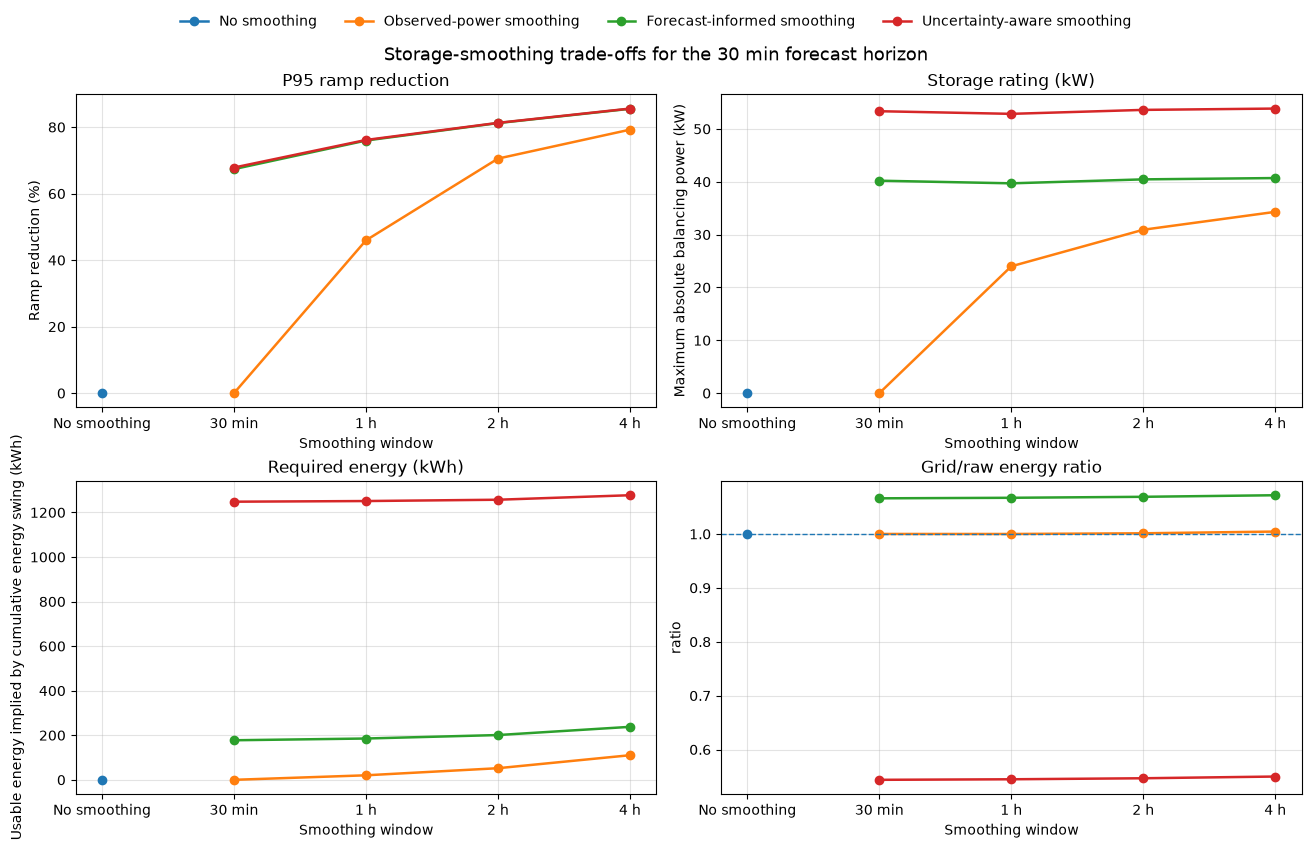

In [20]:
plot_df = storage_metrics_summary[
    storage_metrics_summary["horizon_label"] == "30 min"
].copy()

plot_df["window_order"] = plot_df["smoothing_window_min"]

scenario_order = [
    "A",
    "B",
    "C",
    "D",
]

scenario_name_map = {
    "A": "No smoothing",
    "B": "Observed-power smoothing",
    "C": "Forecast-informed smoothing",
    "D": "Uncertainty-aware smoothing",
}

window_label_map = {
    0: "No smoothing",
    30: "30 min",
    60: "1 h",
    120: "2 h",
    240: "4 h",
}

plot_df["window_label_short"] = plot_df["smoothing_window_min"].map(window_label_map)

metrics_to_plot = [
    [
        "ramp_p95_reduction_percent",
        "P95 ramp reduction",
        "Ramp reduction (%)",
    ],
    [
        "storage_power_rating_kw",
        "Storage rating (kW)",
        "Maximum absolute balancing power (kW)",
    ],
    [
        "required_energy_kwh",
        "Required energy (kWh)",
        "Usable energy implied by cumulative energy swing (kWh)",
    ],
    [
        "grid_to_raw_energy_ratio",
        "Grid/raw energy ratio",
        "ratio",
    ],
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
axes = axes.ravel()

for ax, (metric_col, title, ylabel) in zip(axes, metrics_to_plot):

    for scenario in scenario_order:
        scenario_df = plot_df[plot_df["scenario"] == scenario].sort_values("window_order")

        if scenario_df.empty:
            continue

        ax.plot(
            scenario_df["window_label_short"],
            scenario_df[metric_col],
            marker="o",
            linewidth=1.8,
            label=scenario_name_map[scenario],
        )

    ax.set_title(title)
    ax.set_xlabel("Smoothing window")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.35)

    if metric_col == "grid_to_raw_energy_ratio":
        ax.axhline(1.0, linestyle="--", linewidth=1)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
    ncol=4,
    frameon=False,
)

fig.suptitle(
    "Storage-smoothing trade-offs for the 30 min forecast horizon",
    fontsize=13,
)

fig.savefig(
    FIGURES_DIR / "main_scenario_comparison_30min_horizon.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

The scenario comparison makes the trade-off clearer visually. Longer smoothing windows reduce p95 grid-export ramps, but they also increase the implied storage power and energy requirements. Observed-power smoothing keeps the total grid-target energy close to the observed WEC energy, so it mainly shifts energy through time.

The forecast-informed target gives stronger ramp reduction, but its grid/raw energy ratio stays above 1, indicating a slightly optimistic export target over these test rows. The uncertainty-aware target is more conservative, with a much lower grid/raw energy ratio because it is based on the lower prediction bound.

These results show that the choice of grid-export target matters as much as the smoothing window. Forecasts and prediction intervals change not only the smoothness of delivered power, but also the storage burden and energy balance behind that delivery.


## 6. Forecast-horizon sensitivity

The previous comparison focused on the 30 min forecast horizon. This section checks whether the storage-smoothing conclusions change as the forecast horizon increases.

The figure compares the same core metrics across forecast horizons:

* p95 ramp reduction
* storage power rating
* required usable storage energy
* grid/raw energy ratio

For the smoothing scenarios, 1 h, 2 h, and 4 h smoothing windows are shown together. Scenario color identifies the grid-export target definition, while line style identifies the smoothing window. The no-smoothing case is kept as a solid baseline.

This compact view is intended to show combined trends rather than exact values: how forecast horizon, smoothing-window length, and target definition jointly affect ramp reduction, storage requirements, and grid-energy balance.


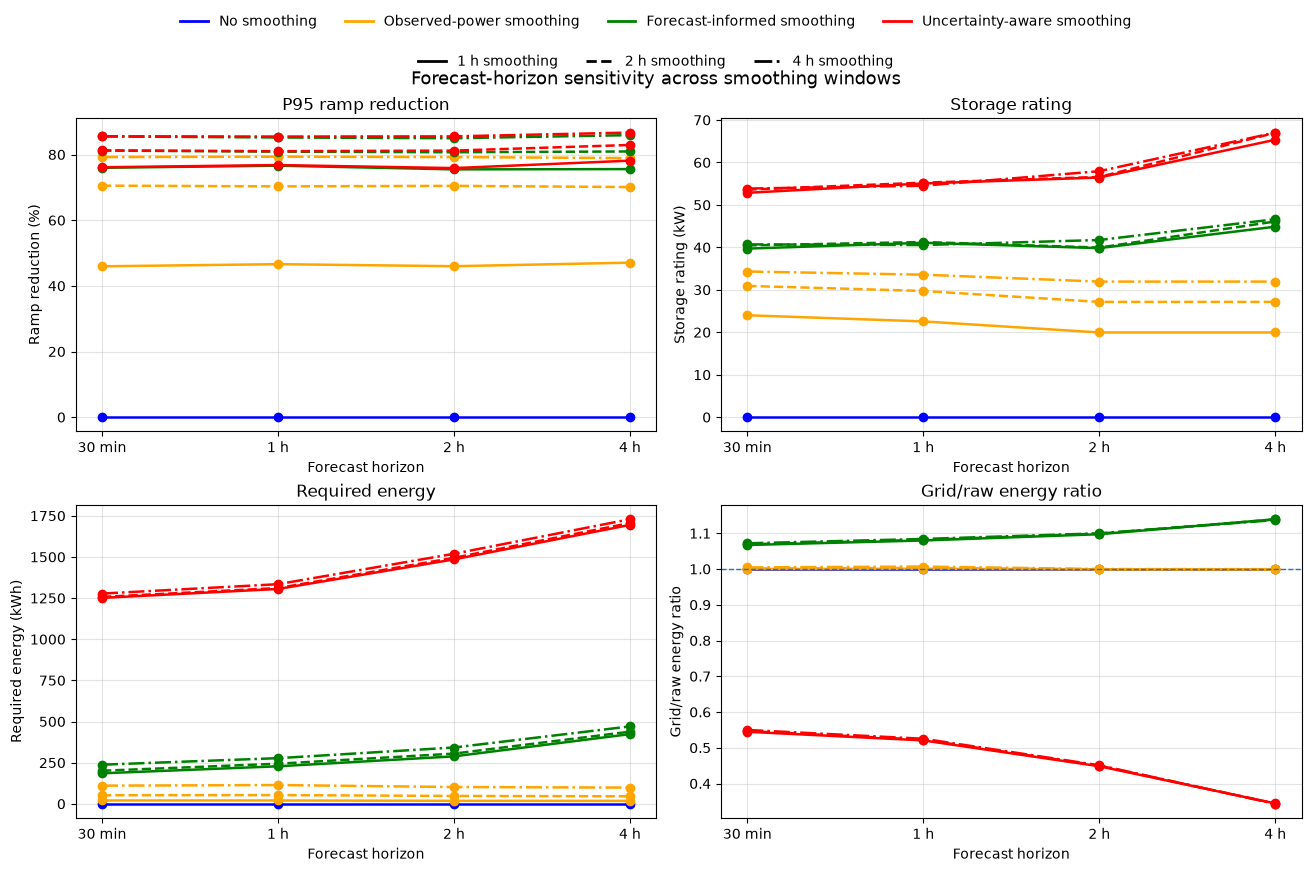

In [22]:
from matplotlib.lines import Line2D

horizon_plot_df = pd.concat(
    [
        storage_metrics_summary[storage_metrics_summary["scenario"] == "A"],
        storage_metrics_summary[
            (storage_metrics_summary["scenario"].isin(["B", "C", "D"]))
            & (storage_metrics_summary["smoothing_window_min"].isin([60, 120, 240]))
        ],
    ],
    ignore_index=True,
)

horizon_plot_df = horizon_plot_df.sort_values(
    ["scenario", "smoothing_window_min", "horizon_steps"]
).copy()

scenario_order = ["A", "B", "C", "D"]

scenario_name_map = {
    "A": "No smoothing",
    "B": "Observed-power smoothing",
    "C": "Forecast-informed smoothing",
    "D": "Uncertainty-aware smoothing",
}

scenario_color_map = {
    "A": "blue",
    "B": "orange",
    "C": "green",
    "D": "red",
}

window_linestyle_map = {
    60: "-",
    120: "--",
    240: "-.",
}

window_label_map = {
    60: "1 h smoothing",
    120: "2 h smoothing",
    240: "4 h smoothing",
}

metrics_to_plot = [
    [
        "ramp_p95_reduction_percent",
        "P95 ramp reduction",
        "Ramp reduction (%)",
    ],
    [
        "storage_power_rating_kw",
        "Storage rating",
        "Storage rating (kW)",
    ],
    [
        "required_energy_kwh",
        "Required energy",
        "Required energy (kWh)",
    ],
    [
        "grid_to_raw_energy_ratio",
        "Grid/raw energy ratio",
        "Grid/raw energy ratio",
    ],
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
axes = axes.ravel()

for ax, (metric_col, title, ylabel) in zip(axes, metrics_to_plot):

    # A: no smoothing baseline
    baseline_df = horizon_plot_df[
        horizon_plot_df["scenario"] == "A"
    ].sort_values("horizon_steps")

    ax.plot(
        baseline_df["horizon_label"],
        baseline_df[metric_col],
        color=scenario_color_map["A"],
        linestyle="-",
        marker="o",
        linewidth=1.8,
    )

    # B/C/D with 1 h, 2 h, and 4 h smoothing
    for scenario in ["B", "C", "D"]:
        for window_min in [60, 120, 240]:
            scenario_df = horizon_plot_df[
                (horizon_plot_df["scenario"] == scenario)
                & (horizon_plot_df["smoothing_window_min"] == window_min)
            ].sort_values("horizon_steps")

            if scenario_df.empty:
                continue

            ax.plot(
                scenario_df["horizon_label"],
                scenario_df[metric_col],
                color=scenario_color_map[scenario],
                linestyle=window_linestyle_map[window_min],
                marker="o",
                linewidth=1.8,
            )

    ax.set_title(title)
    ax.set_xlabel("Forecast horizon")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.35)

    if metric_col == "grid_to_raw_energy_ratio":
        ax.axhline(1.0, linestyle="--", linewidth=1)

# Legend for scenario colors
scenario_handles = [
    Line2D([0], [0], color="blue", linestyle="-", linewidth=2, label="No smoothing"),
    Line2D([0], [0], color="orange", linestyle="-", linewidth=2, label="Observed-power smoothing"),
    Line2D([0], [0], color="green", linestyle="-", linewidth=2, label="Forecast-informed smoothing"),
    Line2D([0], [0], color="red", linestyle="-", linewidth=2, label="Uncertainty-aware smoothing"),
]

# Legend for smoothing-window line styles
window_handles = [
    Line2D([0], [0], color="black", linestyle="-", linewidth=2, label="1 h smoothing"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="2 h smoothing"),
    Line2D([0], [0], color="black", linestyle="-.", linewidth=2, label="4 h smoothing"),
]

fig.legend(
    handles=scenario_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=4,
    frameon=False,
)

fig.legend(
    handles=window_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=3,
    frameon=False,
)

fig.suptitle(
    "Forecast-horizon sensitivity across smoothing windows",
    fontsize=13,
)

fig.savefig(
    FIGURES_DIR / "forecast_horizon_sensitivity_multiple_windows.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

The horizon-sensitivity plot shows that observed-power smoothing is mostly controlled by the smoothing window rather than forecast horizon, because it does not use forecasts. Longer smoothing windows give stronger ramp reduction, with gradually higher storage power and energy requirements.

The forecast-informed target gives stronger ramp reduction than observed-power smoothing, but it also increases the implied storage burden. This happens because the storage system must compensate not only for smoothing, but also for forecast mismatch. The increase is much smaller than in the uncertainty-aware case, but it is clearly larger than smoothing the observed WEC signal directly.

The uncertainty-aware target becomes more conservative as the forecast horizon increases. The lower prediction bound moves farther below the realized WEC power, so the grid/raw energy ratio decreases and the required energy rises. This highlights the cost of using uncertainty to reduce under-delivery risk: the grid target becomes smoother and safer, but more surplus or curtailment-like energy appears.

Overall, forecasting can support smoother grid-export targets, but forecast errors and bias transfer part of the forecasting problem into the storage system. Prediction intervals add useful risk awareness, but a lower-bound target should be interpreted as a conservative commitment rule rather than a direct BESS-sizing recommendation.
